# 3.0 Uncertainty Propagation

EKF covariance: Gamma_{k+1} = F * Gamma_k * F^T + W*dt

Trace growth: 0.012500 -> 0.081559 (6.5x)


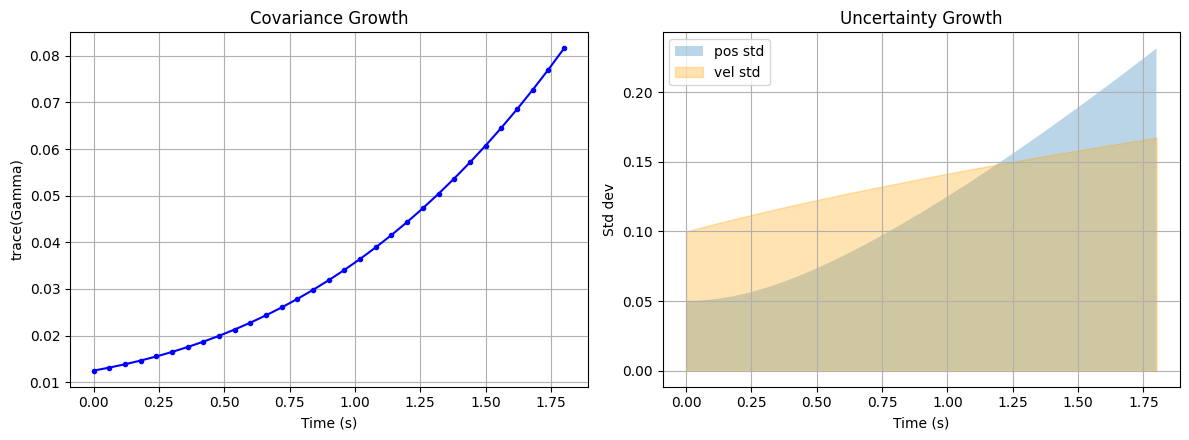

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
import os; os.makedirs('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs', exist_ok=True)

dt = 0.06; N = 30
F = np.array([[1, dt], [0, 1]])
W = np.diag([0.01**2, 0.1**2])

Gamma0 = np.diag([0.05**2, 0.1**2])
Gamma_list = [Gamma0.copy()]
traces = [np.trace(Gamma0)]

for k in range(N):
    Gk = Gamma_list[-1]
    Gk1 = F @ Gk @ F.T + W * dt
    Gamma_list.append(Gk1)
    traces.append(np.trace(Gk1))

print("Trace growth: %.6f -> %.6f (%.1fx)" % (traces[0], traces[-1], traces[-1]/traces[0]))
assert all(traces[i] > traces[i-1] for i in range(1, len(traces)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(np.arange(N+1)*dt, traces, 'b-o', markersize=3)
ax1.set_xlabel('Time (s)'); ax1.set_ylabel('trace(Gamma)')
ax1.set_title('Covariance Growth'); ax1.grid(True)

pos_std = [sqrt(G[0,0]) for G in Gamma_list]
vel_std = [sqrt(G[1,1]) for G in Gamma_list]
ax2.fill_between(np.arange(N+1)*dt, pos_std, alpha=0.3, label='pos std')
ax2.fill_between(np.arange(N+1)*dt, vel_std, alpha=0.3, label='vel std', color='orange')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Std dev')
ax2.set_title('Uncertainty Growth'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs/3.0_uncertainty.png', dpi=100, bbox_inches='tight')
plt.show()


# Summary

Covariance grows monotonically. Position covariance extracted for chance constraints.